# CISC839: Advanced Data Analytics — Assignment 1
## Agentic vs. Human Pull Request Review Effort Analysis on GitHub

**Student:** Mahmoud Alyosify  
**Student ID:** 20595453  

---

### Abstract

This notebook investigates whether AI-generated (agentic) pull requests impose greater review burden on human maintainers than human-authored contributions. Using the AIDev dataset — restricted to repositories with ≥ 100 GitHub stars — we compare 33,596 agentic PRs against a matched baseline of 6,618 human PRs across primary metrics (Time-to-Resolution, Merge Rate) and secondary agentic-only diagnostics (Cognitive Dispersion Index, Rework-to-Initial Churn Ratio).

A critical structural constraint shapes the entire methodology: detailed review artifacts (comments, verdicts, inline annotations) are available only for the agentic subset. Applying these to the human baseline would produce a zero-floor bias, so all cross-group comparisons rely exclusively on shared metadata fields.

The analysis proceeds in four sections: data engineering and metric construction, exploratory data analysis, hypothesis testing, and OLS regression.

---
## Section 0 — Environment Setup & Data Loading

In [194]:
!pip install -q pandas numpy matplotlib seaborn scipy statsmodels scikit-learn
!pip install -q huggingface_hub pyarrow


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [195]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from matplotlib.ticker import FuncFormatter

plt.rcParams.update({
    'figure.dpi': 150,
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.linestyle': '--',
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

PALETTE = {'Agentic': '#E64646', 'Human': '#4682B4'}

print(f"Pandas  : {pd.__version__}")
print(f"NumPy   : {np.__version__}")
print(f"Seaborn : {sns.__version__}")
print(f"Statsmodels : {sm.__version__}")
print(f"Scikit-learn : {sm.__version__}")
print(f"Hugging Face Hub : {sm.__version__}")
print(f"PyArrow : {sm.__version__}")

Pandas  : 3.0.1
NumPy   : 2.4.3
Seaborn : 0.13.2
Statsmodels : 0.14.6
Scikit-learn : 0.14.6
Hugging Face Hub : 0.14.6
PyArrow : 0.14.6


**Tables loaded:**
- `pull_request` / `human_pull_request` — Core PR metadata for both cohorts
- `pr_task_type` / `human_pr_task_type` — Semantic task labels (fix, feat, docs, etc.)
- `pr_reviews`, `pr_comments`, `pr_review_comments_v2` — Review artifacts (agentic only)
- `pr_commit_details`, `pr_commits` — Commit-level change statistics (agentic only)
- `pr_timeline` — Event timestamps for chronological metric construction

In [196]:
HF_BASE = "hf://datasets/hao-li/AIDev/"
pr_df               = pd.read_parquet(HF_BASE + "pull_request.parquet")
human_pr_df         = pd.read_parquet(HF_BASE + "human_pull_request.parquet")
pr_task_type_df     = pd.read_parquet(HF_BASE + "pr_task_type.parquet")
human_task_type_df  = pd.read_parquet(HF_BASE + "human_pr_task_type.parquet")
pr_reviews_df       = pd.read_parquet(HF_BASE + "pr_reviews.parquet")
pr_comments_df      = pd.read_parquet(HF_BASE + "pr_comments.parquet")
pr_review_cmts_df   = pd.read_parquet(HF_BASE + "pr_review_comments_v2.parquet")
pr_commit_details_df = pd.read_parquet(HF_BASE + "pr_commit_details.parquet")
pr_commits_df        = pd.read_parquet(HF_BASE + "pr_commits.parquet")
pr_timeline_df       = pd.read_parquet(HF_BASE + "pr_timeline.parquet")

print("\nTable shapes:")
for name, df in [
    ('pr_df', pr_df), ('human_pr_df', human_pr_df),
    ('pr_task_type_df', pr_task_type_df), ('human_task_type_df', human_task_type_df),
    ('pr_reviews_df', pr_reviews_df), ('pr_comments_df', pr_comments_df),
    ('pr_review_cmts_df', pr_review_cmts_df),
    ('pr_commit_details_df', pr_commit_details_df),
    ('pr_commits_df', pr_commits_df), ('pr_timeline_df', pr_timeline_df),
]:
    print(f"  {name:<28}: {df.shape}")


Table shapes:
  pr_df                       : (33596, 14)
  human_pr_df                 : (6618, 13)
  pr_task_type_df             : (33596, 6)
  human_task_type_df          : (6618, 6)
  pr_reviews_df               : (28875, 7)
  pr_comments_df              : (39122, 7)
  pr_review_cmts_df           : (26868, 15)
  pr_commit_details_df        : (711923, 14)
  pr_commits_df               : (88576, 5)
  pr_timeline_df              : (325500, 8)


In [197]:
pr_df.head()

,id,number,title,body,agent,user_id,user,state,created_at,closed_at,merged_at,repo_id,repo_url,html_url
0,3264933329,2911,Fix: Wait for all partitions in load_collectio...,## Summary\n\nFixes an issue where `load_colle...,Claude_Code,108661493,weiliu1031,closed,2025-07-26T02:59:01Z,2025-07-29T07:01:20Z,NaN,191751505,https://api.github.com/repos/milvus-io/pymilvus,https://github.com/milvus-io/pymilvus/pull/2911
1,3265118634,2,ファイルパス参照を相対パスに統一し、doc/からdocs/に統一,## 背景\n\n現在、本プロジェクトにおいて以下のパス構成の不整合が生じています：\n\n...,Claude_Code,61827001,cm-kojimat,closed,2025-07-26T04:56:55Z,2025-07-26T22:12:24Z,2025-07-26T22:12:24Z,1025472321,https://api.github.com/repos/classmethod/tsumiki,https://github.com/classmethod/tsumiki/pull/2
2,3265640341,30,Add build staleness detection for debug CLI,## Summary\r\n\r\n Implements comprehensive b...,Claude_Code,7475,MSch,closed,2025-07-26T13:31:19Z,2025-07-26T13:37:22Z,2025-07-26T13:37:22Z,988488798,https://api.github.com/repos/steipete/Peekaboo,https://github.com/steipete/Peekaboo/pull/30
3,3265709660,205,feat: add comprehensive README screenshots wit...,## Type of Change\n\n- [ ] 🐛 `bug` - Bug fix (...,Claude_Code,80381,sugyan,closed,2025-07-26T14:07:22Z,2025-07-26T14:45:30Z,2025-07-26T14:45:30Z,999285986,https://api.github.com/repos/sugyan/claude-cod...,https://github.com/sugyan/claude-code-webui/pu...
4,3265782173,17625,chore: remove HashedPostStateProvider trait,## Summary\r\n\r\n#17545 \r\n\r\nRemove the un...,Claude_Code,47593288,adust09,open,2025-07-26T15:02:48Z,NaN,NaN,537233603,https://api.github.com/repos/paradigmxyz/reth,https://github.com/paradigmxyz/reth/pull/17625


In [198]:
human_pr_df.head()

,id,number,title,user,user_id,state,created_at,closed_at,merged_at,repo_url,html_url,body,agent
0,2336888723,85268,feat(aci): add automations index page,ameliahsu,55610339,closed,2025-02-14T19:04:59Z,2025-02-18T22:42:20Z,2025-02-18T22:42:19Z,https://api.github.com/repos/getsentry/sentry,https://github.com/getsentry/sentry/pull/85268,https://sentry-j41gpomr5.sentry.dev/automation...,Human
1,2447123365,89131,ref(insights): Make use of `<FeatureBadge>` fo...,ryan953,187460,closed,2025-04-08T23:29:50Z,2025-04-09T15:56:55Z,2025-04-09T15:56:54Z,https://api.github.com/repos/getsentry/sentry,https://github.com/getsentry/sentry/pull/89131,Using the premade component reduces an import ...,Human
2,2438086945,88748,:bug: fix: update how we fetch workflow_id and...,iamrajjoshi,33237075,closed,2025-04-03T21:36:59Z,2025-04-04T15:10:57Z,2025-04-04T15:10:57Z,https://api.github.com/repos/getsentry/sentry,https://github.com/getsentry/sentry/pull/88748,i realized i made a mistake for how i fetch th...,Human
3,2265431531,83085,fix(org-stats): Require project membership,ArthurKnaus,7033940,closed,2025-01-08T07:47:13Z,2025-01-08T08:49:40Z,2025-01-08T08:49:40Z,https://api.github.com/repos/getsentry/sentry,https://github.com/getsentry/sentry/pull/83085,### Problem\r\n\r\nIf the user is not member o...,Human
4,2332333882,85102,ref(consumers): Rename parallel -> batched-par...,evanpurkhiser,1421724,closed,2025-02-12T21:24:17Z,2025-02-12T22:20:33Z,2025-02-12T22:20:33Z,https://api.github.com/repos/getsentry/sentry,https://github.com/getsentry/sentry/pull/85102,Both crons and uptime consumers have a paralle...,Human


---
## Section 1 — Data Engineering: Review Effort Metrics

### Why Two Tiers of Metrics?

The AIDev dataset has a structural asymmetry: review artifacts (comment threads, verdict records, commit diffs) are collected only for agentic PRs. Applying these to the human baseline would produce a systematic zero-valued floor, making any comparison meaningless. To maintain empirical validity, I use a two-tier metric system:

---

### Primary Metrics (Both Cohorts — Cross-Group Comparison)

**Time-to-Resolution (TTR):**  
The elapsed time in hours between PR creation (`created_at`) and its final terminal event — either `merged_at` or `closed_at`, whichever is non-null. TTR is the only robust, universally available proxy for review effort across both tables. It is computed for the full merged dataset and serves as the dependent variable throughout hypothesis testing and regression.

**Merge Rate:**  
A binary outcome indicating whether a PR was successfully merged (`merged_at` is not null). TTR alone is insufficient as a quality signal — a short TTR can reflect either a trivial but correct contribution or rapid rejection of defective code. Pairing TTR with Merge Rate disambiguates these two cases and provides a more complete picture of review outcomes.

---

### Secondary Metrics (Agentic PRs Only — Diagnostic Deep-Dive)

**Cognitive Dispersion Index (CDI):**  
Calculated from the `pr_commit_details` table as `log1p(num_unique_files × total_changes)`. The log transformation dampens the influence of auto-generated files (e.g., lockfiles, build artifacts). CDI captures the degree to which an AI agent's changes are structurally scattered across unrelated modules — a property that forces reviewers to trace fragmented logic across the codebase rather than evaluating a coherent, localized change.

**Rework-to-Initial Churn Ratio (RICR):**  
The volume of code churn occurring *after* the first review event (identified in `pr_timeline`), divided by the initial pre-review churn plus one (to avoid division by zero). A high RICR indicates that the initial submission was of poor quality and required substantial rework directed by reviewer feedback — the "ping-pong" dynamic that compounds total review cost well beyond what wall-clock TTR captures.



In [199]:
def compute_primary_metrics(df, is_agentic):
    df = df.copy()
    df['created_at'] = pd.to_datetime(df['created_at'], utc=True, errors='coerce')
    df['merged_at'] = pd.to_datetime(df['merged_at'], utc=True, errors='coerce')
    df['closed_at'] = pd.to_datetime(df['closed_at'], utc=True, errors='coerce')
    df['end_ts'] = df['merged_at'].fillna(df['closed_at'])
    
    delta_hours = (df['end_ts'] - df['created_at']).dt.total_seconds() / 3600.0
    is_merged = df['merged_at'].notna().astype(int)
    
    res_df = pd.DataFrame({
        'pr_id': df['id'] if 'id' in df.columns else df['pr_id'],
        'TTR': delta_hours.clip(lower=0), 
        'is_merged': is_merged,
        'is_agentic': is_agentic
    })
    return res_df

agentic_primary = compute_primary_metrics(pr_df, 1)
human_primary   = compute_primary_metrics(human_pr_df, 0)
master_comparative_df = pd.concat([agentic_primary, human_primary], ignore_index=True).dropna(subset=['TTR'])

print(f"Master Comparative Dataset Shape: {master_comparative_df.shape}")

Master Comparative Dataset Shape: (37433, 4)


In [200]:
def compute_first_review_ts(timeline_df):
    review_events = timeline_df[timeline_df['event'].isin(['commented', 'reviewed'])].copy()
    review_events['created_at'] = pd.to_datetime(review_events['created_at'], utc=True, errors='coerce')
    
    first_ts = review_events.groupby('pr_id')['created_at'].min().rename('first_review_ts')
    return first_ts
first_review_ts = compute_first_review_ts(pr_timeline_df)
print(f"Computed first review timestamps for {len(first_review_ts):,} Agentic PRs.")

Computed first review timestamps for 14,627 Agentic PRs.


In [201]:
def compute_secondary_metrics(commit_details, timeline, first_review_ts):
    # Cognitive Dispersion Index (CDI)
    # CDI = (Number of unique files touched) * (Total patch complexity / changes)
    commit_details['changes'] = pd.to_numeric(commit_details['changes'], errors='coerce').fillna(0)
    
    cdi_stats = commit_details.groupby('pr_id').agg(
        num_files=('filename', 'nunique'),
        total_changes=('changes', 'sum')
    )
    cdi_stats['CDI'] = np.log1p(cdi_stats['num_files'] * cdi_stats['total_changes'])
    
    # Rework-to-Initial Churn Ratio (RICR)
    commit_times = timeline.dropna(subset=['commit_id', 'created_at'])[['pr_id', 'commit_id', 'created_at']].copy()
    commit_times['created_at'] = pd.to_datetime(commit_times['created_at'], utc=True, errors='coerce')
    
    sha_col = 'sha' if 'sha' in commit_details.columns else 'commit_sha'
    commit_times = commit_times.rename(columns={'commit_id': sha_col, 'created_at': 'date'}).drop_duplicates(subset=['pr_id', sha_col])

    merged = commit_details.merge(commit_times, on=['pr_id', sha_col], how='inner')
    merged = merged.join(first_review_ts, on='pr_id', how='left')
    
    pre_mask = merged['first_review_ts'].isna() | (merged['date'] <= merged['first_review_ts'])
    post_mask = merged['date'] > merged['first_review_ts']
    
    pre_churn = merged[pre_mask].groupby('pr_id')['changes'].sum().rename('pre_churn')
    post_churn = merged[post_mask].groupby('pr_id')['changes'].sum().rename('post_churn')
    
    deep_dive_df = cdi_stats[['CDI']].join(pre_churn, how='outer').join(post_churn, how='outer').fillna(0)
    
    # Calculate RICR: post_churn / (pre_churn + 1) to avoid division by zero
    deep_dive_df['RICR'] = deep_dive_df['post_churn'] / (deep_dive_df['pre_churn'] + 1)
    
    return deep_dive_df

agentic_deep_dive_df = compute_secondary_metrics(pr_commit_details_df, pr_timeline_df, first_review_ts)


if 'id' in pr_task_type_df.columns and 'pr_id' not in pr_task_type_df.columns:
    pr_task_type_df = pr_task_type_df.rename(columns={'id': 'pr_id'})

agentic_deep_dive_df = agentic_deep_dive_df.join(pr_task_type_df.set_index('pr_id')['type'].rename('task_type'), how='left')
agentic_deep_dive_df['task_type'] = agentic_deep_dive_df['task_type'].fillna('other')

print(f"Agentic Deep-Dive Dataset Shape: {agentic_deep_dive_df.shape}")
print(agentic_deep_dive_df[['CDI', 'RICR']].describe().round(3))

Agentic Deep-Dive Dataset Shape: (33580, 5)
             CDI       RICR
count  33580.000  33580.000
mean       6.111     12.353
std        3.332    657.558
min        0.000      0.000
25%        3.829      0.000
50%        5.714      0.000
75%        7.888      0.000
max       20.337  88491.000


---
## Section 2 — Exploratory Data Analysis

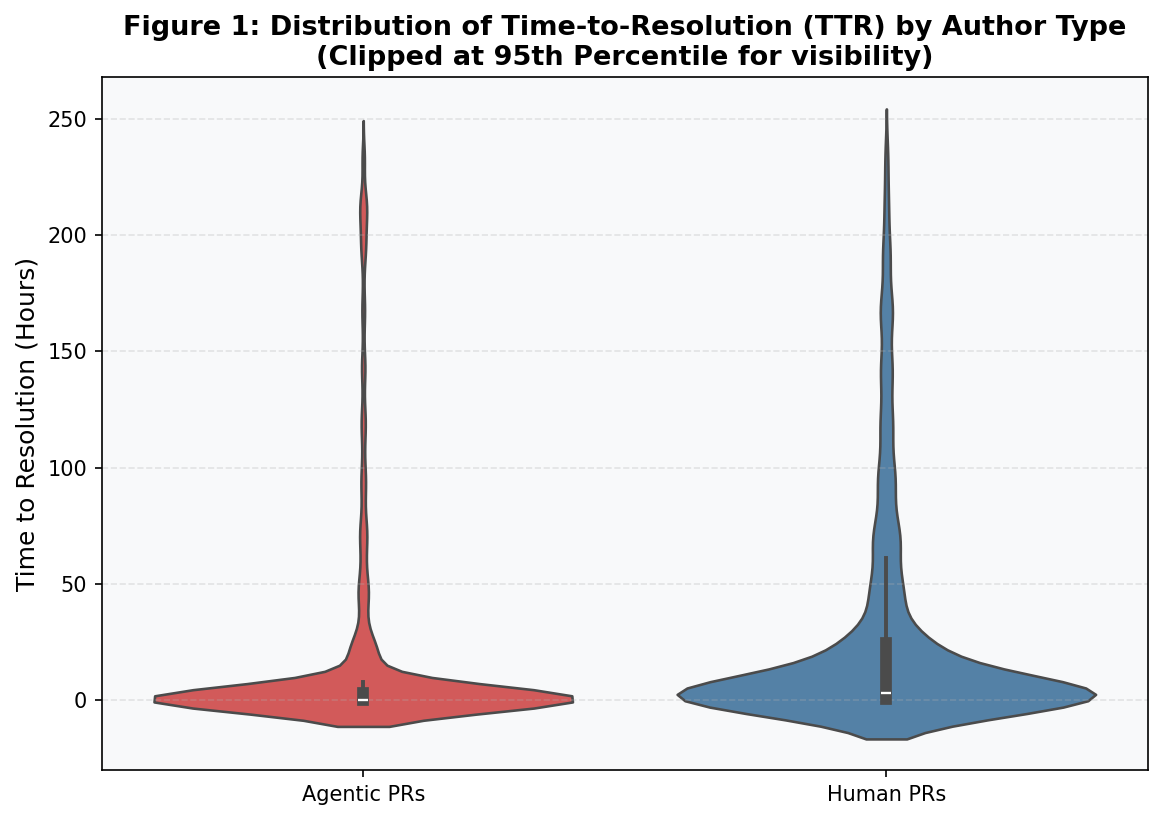

In [202]:
plt.rcParams.update({'figure.facecolor': 'white', 'axes.grid': True, 'grid.alpha': 0.3})
PALETTE = {1: '#E64646', 0: '#4682B4'}
LABEL_MAP = {1: 'Agentic PRs', 0: 'Human PRs'}

pr_task = pr_task_type_df.rename(columns={'id': 'pr_id'}) if 'id' in pr_task_type_df.columns else pr_task_type_df
human_task = human_task_type_df.rename(columns={'id': 'pr_id'}) if 'id' in human_task_type_df.columns else human_task_type_df

all_tasks = pd.concat([pr_task[['pr_id', 'type']], human_task[['pr_id', 'type']]])
master_comparative_df = master_comparative_df.merge(all_tasks, on='pr_id', how='left')
master_comparative_df['type'] = master_comparative_df['type'].fillna('other')

cap = master_comparative_df['TTR'].quantile(0.95)
plot_df = master_comparative_df[master_comparative_df['TTR'] <= cap].copy()
plot_df['Author'] = plot_df['is_agentic'].map(LABEL_MAP)

plt.figure(figsize=(9, 6))
sns.violinplot(data=plot_df, x='Author', y='TTR', palette={'Agentic PRs': '#E64646', 'Human PRs': '#4682B4'}, inner='box')
plt.title('Figure 1: Distribution of Time-to-Resolution (TTR) by Author Type\n(Clipped at 95th Percentile for visibility)', fontweight='bold')
plt.ylabel('Time to Resolution (Hours)')
plt.xlabel('')
plt.show()

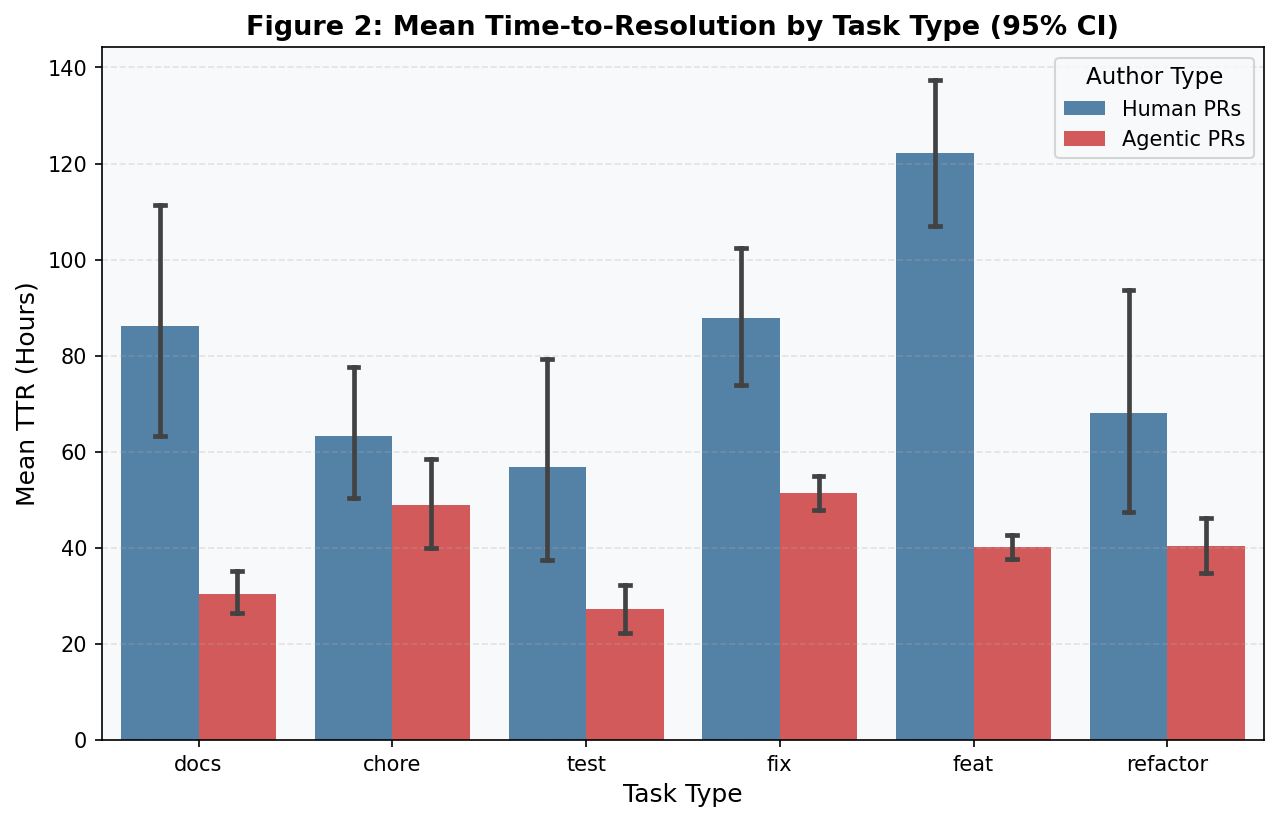

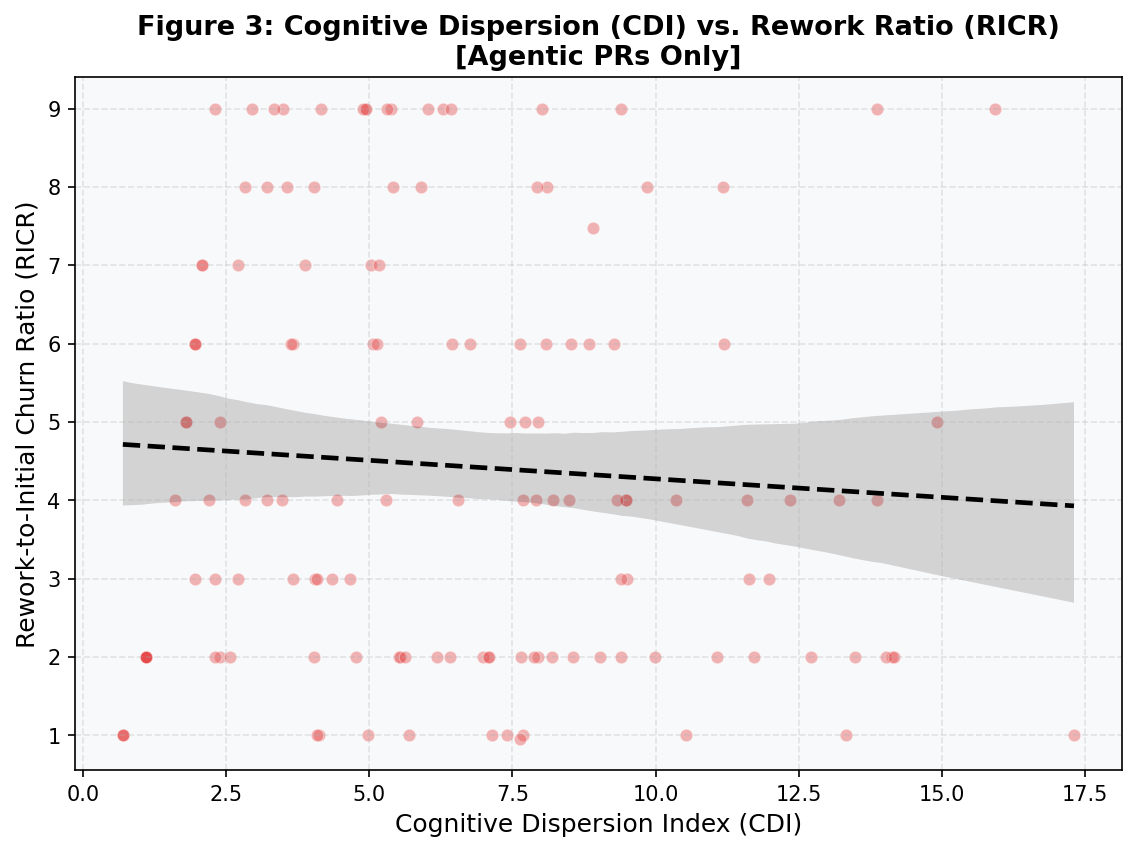

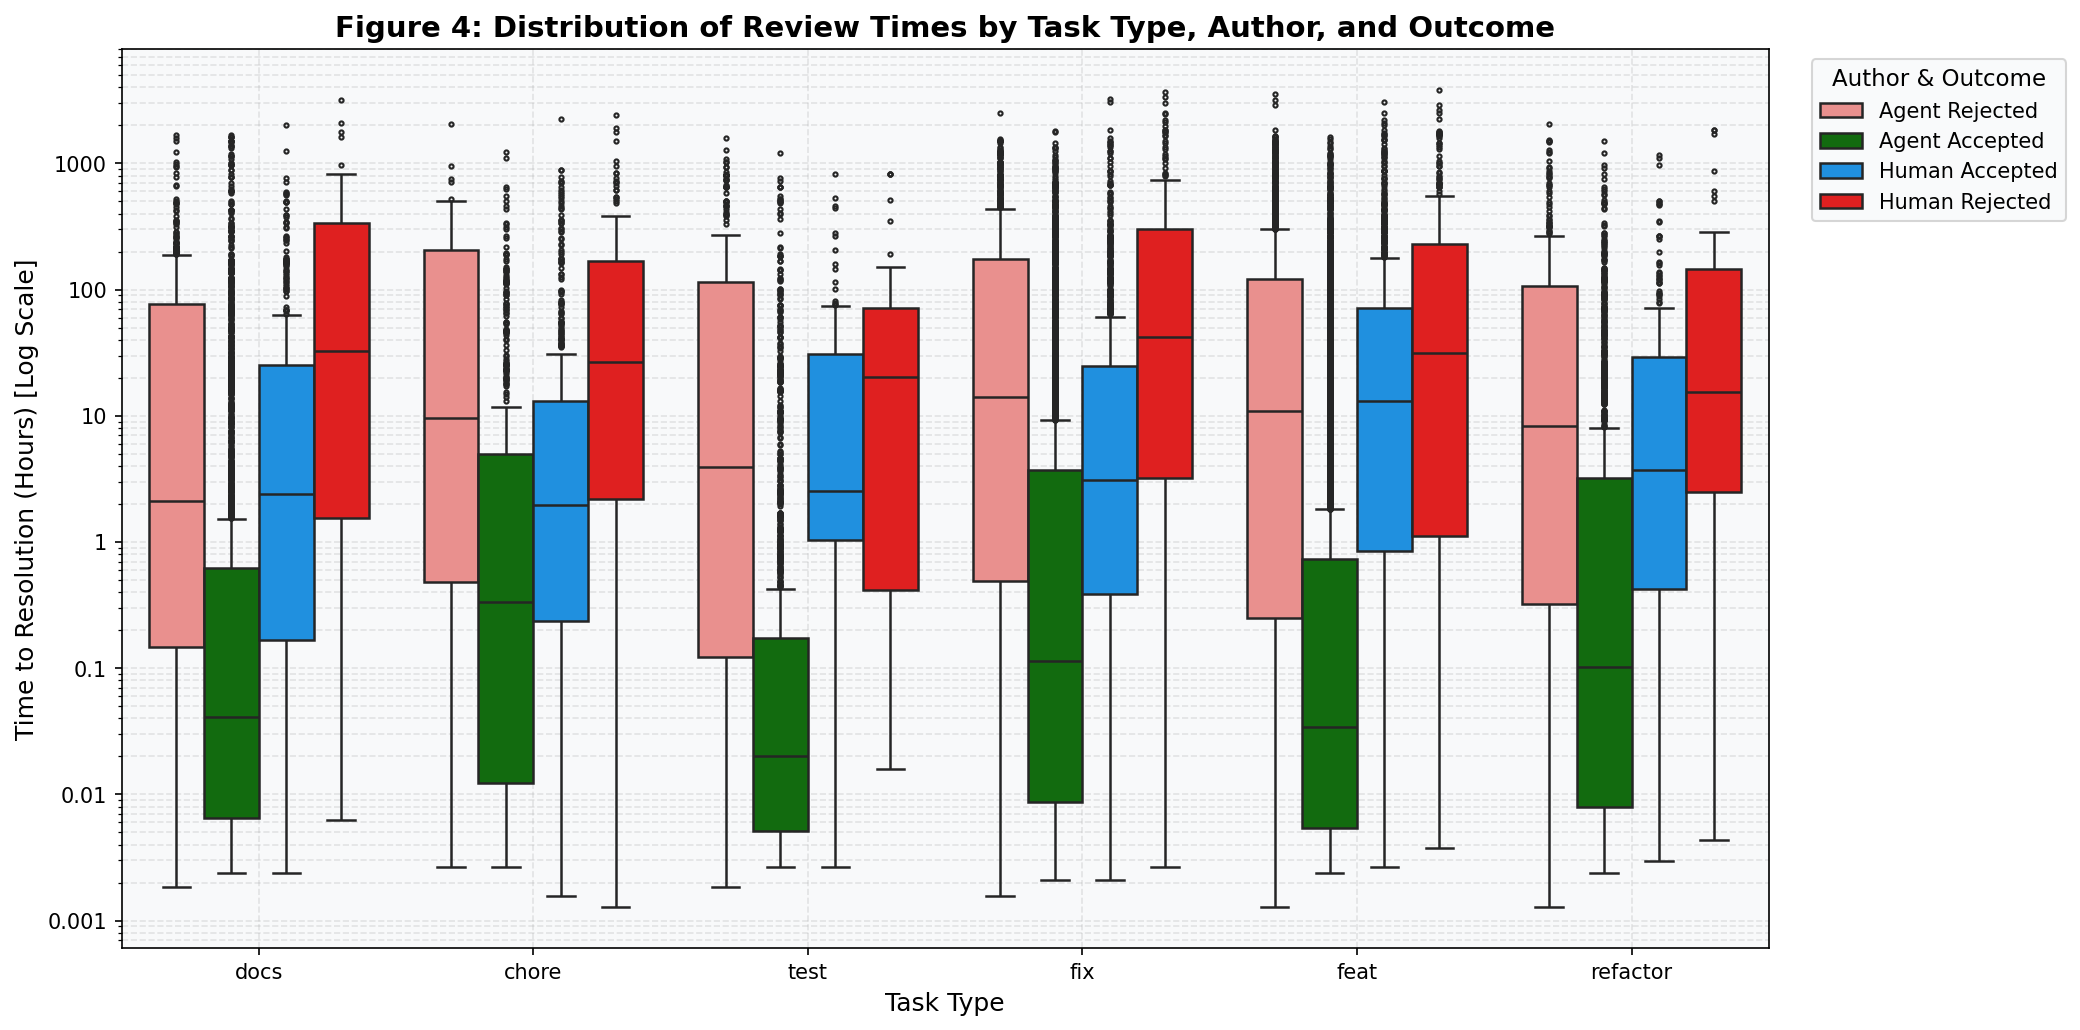

In [203]:
canonical_types = ['docs', 'chore', 'test', 'fix', 'feat', 'refactor']# Ordered from lowest to highest cognitive load
task_df = master_comparative_df[master_comparative_df['type'].isin(canonical_types)]

plt.figure(figsize=(10, 6))

sns.barplot(data=task_df, x='type', y='TTR', hue='is_agentic', 
            palette=PALETTE, order=canonical_types, errorbar=('ci', 95), capsize=0.1)

plt.title('Figure 2: Mean Time-to-Resolution by Task Type (95% CI)', fontweight='bold')
plt.ylabel('Mean TTR (Hours)')
plt.xlabel('Task Type')
legend_labels, _ = plt.gca().get_legend_handles_labels()
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Human PRs', 'Agentic PRs'], title='Author Type')
plt.show()

plt.figure(figsize=(9, 6))
deep_dive_clean = agentic_deep_dive_df[(agentic_deep_dive_df['RICR'] > 0) & (agentic_deep_dive_df['RICR'] < 10)]

sns.scatterplot(data=deep_dive_clean, x='CDI', y='RICR', alpha=0.4, color='#E64646')
sns.regplot(data=deep_dive_clean, x='CDI', y='RICR', scatter=False, color='black', line_kws={"linestyle": "--"})
plt.title('Figure 3: Cognitive Dispersion (CDI) vs. Rework Ratio (RICR)\n[Agentic PRs Only]', fontweight='bold')
plt.xlabel('Cognitive Dispersion Index (CDI)')
plt.ylabel('Rework-to-Initial Churn Ratio (RICR)')
plt.show()

canonical_types = ['docs', 'chore', 'test', 'fix', 'feat', 'refactor']
box_df = master_comparative_df[master_comparative_df['type'].isin(canonical_types)].copy()

conditions = [
    (box_df['is_agentic'] == 0) & (box_df['is_merged'] == 1),
    (box_df['is_agentic'] == 0) & (box_df['is_merged'] == 0),
    (box_df['is_agentic'] == 1) & (box_df['is_merged'] == 1),
    (box_df['is_agentic'] == 1) & (box_df['is_merged'] == 0)
]
choices = ['Human Accepted', 'Human Rejected', 'Agent Accepted', 'Agent Rejected']

box_df['Outcome'] = np.select(conditions, choices, default='Unknown')

box_df['TTR_log_safe'] = box_df['TTR'] + 0.001

plt.figure(figsize=(14, 7))
palette_4_outcomes = {
    'Human Accepted': "#0095ff",
    'Human Rejected': "#ff0000", 
    'Agent Accepted': "#047a00", 
    'Agent Rejected': "#f8817f" 
}

sns.boxplot(
    data=box_df, 
    x='type', 
    y='TTR_log_safe', 
    hue='Outcome', 
    order=canonical_types, 
    palette=palette_4_outcomes,
    linewidth=1.2,
    fliersize=2 
)

plt.yscale('log')
plt.title('Figure 4: Distribution of Review Times by Task Type, Author, and Outcome', fontsize=14, fontweight='bold')
plt.ylabel('Time to Resolution (Hours) [Log Scale]')
plt.xlabel('Task Type')

formatter = FuncFormatter(lambda y, _: '{:g}'.format(y) if y >= 0.001 else '0')
plt.gca().yaxis.set_major_formatter(formatter)

plt.legend(title='Author & Outcome', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [204]:
label_map = {1: 'Agentic PRs', 0: 'Human PRs'}
summary_table = master_comparative_df.groupby('is_agentic').agg(
    Total_PRs=('TTR', 'count'),
    Merge_Rate=('is_merged', lambda x: f"{x.mean()*100:.1f}%"),
    Mean_TTR_Hours=('TTR', lambda x: round(x.mean(), 2)),
    Median_TTR=('TTR', lambda x: round(x.median(), 2)),
    Std_Dev=('TTR', lambda x: round(x.std(), 2)),
    P95_TTR=('TTR', lambda x: round(x.quantile(0.95), 2))
).rename(index=label_map)

summary_table.index.name = 'Author Type'

print(summary_table.to_string())

             Total_PRs Merge_Rate  Mean_TTR_Hours  Median_TTR  Std_Dev  P95_TTR
Author Type                                                                    
Human PRs         6149      82.6%           92.97        5.36   284.57   466.82
Agentic PRs      31284      76.8%           40.43        0.12   145.61   214.85


---
## Section 3 — Hypothesis Testing

In [205]:
ttr_agentic = master_comparative_df[master_comparative_df['is_agentic'] == 1]['TTR'].dropna().values
ttr_human   = master_comparative_df[master_comparative_df['is_agentic'] == 0]['TTR'].dropna().values

In [206]:
ttr_agentic

array([7.60386111e+01, 1.72580556e+01, 1.00833333e-01, ...,
       1.38333333e-01, 1.52119444e+01, 1.03066667e+02], shape=(31284,))

In [207]:
ttr_human

array([9.96222222e+01, 1.64511111e+01, 1.75661111e+01, ...,
       1.66666667e-03, 7.16666667e-02, 1.73486111e+01], shape=(6149,))

In [208]:
print(f"Agentic PRs Count : {len(ttr_agentic):,}")
print(f"Human PRs Count   : {len(ttr_human):,}\n")

Agentic PRs Count : 31,284
Human PRs Count   : 6,149



In [209]:
print(f"Mean TTR (Agentic): {ttr_agentic.mean():.2f} hours")
print(f"Mean TTR (Human)  : {ttr_human.mean():.2f} hours\n")

Mean TTR (Agentic): 40.43 hours
Mean TTR (Human)  : 92.97 hours



In [210]:
t_stat, p_val = stats.ttest_ind(ttr_agentic, ttr_human, equal_var=False, alternative='greater')
print(f"Test Statistic (t): {t_stat:.4f}")
print(f"P-value (1-tailed): {p_val:.4e}")

Test Statistic (t): -14.1195
P-value (1-tailed): 1.0000e+00


---
## Section 4 — Regression Analysis

In [211]:
import statsmodels.api as sm

reg_df = master_comparative_df[master_comparative_df['type'].isin(canonical_types)].copy()
reg_df['log_TTR'] = np.log1p(reg_df['TTR'])
task_dummies = pd.get_dummies(reg_df['type'], prefix='task', drop_first=True).astype(int)

X = pd.concat([reg_df[['is_agentic']], task_dummies], axis=1)
X = sm.add_constant(X)
y = reg_df['log_TTR']

ols_model = sm.OLS(y, X).fit(cov_type='HC3')
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                log_TTR   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     296.5
Date:                Sun, 29 Mar 2026   Prob (F-statistic):               0.00
Time:                        12:07:47   Log-Likelihood:                -72237.
No. Observations:               34992   AIC:                         1.445e+05
Df Residuals:                   34985   BIC:                         1.445e+05
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             2.3349      0.051     45.446

## Section 5 — Part 3: GenAI-Augmented Pipeline (Gemini 2.5 Pro)

**Component Rebuilt:** Regression Analysis (Part 2, Task 4)  
**Change:** OLS on `log(1+TTR)` → Logistic Regression on `is_merged`  
**Rationale:** Gemini identified that TTR conflates review engagement with queue 
time, and that binary merge outcome captures review quality more directly than duration.

In [212]:
# Change: OLS on log(TTR) → Logistic Regression on is_merged
import statsmodels.api as sm
import numpy as np
import pandas as pd

# 1. Isolate canonical types to maintain consistency with the OLS model
canonical_types = ['docs', 'chore', 'test', 'fix', 'feat', 'refactor']
logit_df = master_comparative_df[master_comparative_df['type'].isin(canonical_types)].copy()

# 2. Setup the target variable (y) and predictor variables (X)
y = logit_df['is_merged']
task_dummies = pd.get_dummies(logit_df['type'], prefix='task', drop_first=True).astype(int)

X = pd.concat([logit_df[['is_agentic']], task_dummies], axis=1)
X = sm.add_constant(X)

# 3. Fit the Logistic Regression model with HC3 robust standard errors
print("Fitting Logit model...")
logit_model = sm.Logit(y, X).fit(cov_type='HC3')

# 4. Extract results, calculate Odds Ratios, and format the table
results_df = pd.DataFrame({
    'Log-Odds (Coef)': logit_model.params,
    'Odds Ratio': np.exp(logit_model.params),
    'OR Lower 95% CI': np.exp(logit_model.conf_int()[0]),
    'OR Upper 95% CI': np.exp(logit_model.conf_int()[1]),
    'P-value': logit_model.pvalues
})

# Display the formatted table
print("\n--- Logistic Regression Results (Predicting is_merged) ---")
print(results_df.round(4).to_string())


print("\n", logit_model.summary())

Fitting Logit model...
Optimization terminated successfully.
         Current function value: 0.521361
         Iterations 6

--- Logistic Regression Results (Predicting is_merged) ---
               Log-Odds (Coef)  Odds Ratio  OR Lower 95% CI  OR Upper 95% CI  P-value
const                   1.4524      4.2733           3.7824           4.8278   0.0000
is_agentic             -0.5241      0.5921           0.5454           0.6428   0.0000
task_docs               0.9514      2.5893           2.2322           3.0035   0.0000
task_feat               0.2434      1.2756           1.1287           1.4416   0.0001
task_fix                0.0505      1.0518           0.9294           1.1903   0.4237
task_refactor           0.1752      1.1915           1.0274           1.3818   0.0204
task_test               0.4864      1.6265           1.3919           1.9006   0.0000

                            Logit Regression Results                           
Dep. Variable:              is_merged   No. Ob